In [1]:
# ============================================================
# PHASE 5 — FORECASTING SETUP
# Create the training and test datasets for time-series forecasting
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


# ============================================================
# Load the cleaned UPI dataset
# ============================================================

df = pd.read_csv(
    "../data/clean/upi_clean.csv",
    parse_dates=["date"]
)


# Keep the time series in chronological order
df = df.sort_values(
    "date"
).reset_index(drop=True)


# ============================================================
# Define the forecasting target
# Monthly UPI transaction volume will be forecast
# ============================================================

target = "volume_mn"


# ============================================================
# Reserve the latest 6 months as the test set
# April 2026 to September 2026
# ============================================================

test_months = 6

train = df.iloc[:-test_months].copy()
test = df.iloc[-test_months:].copy()


# ============================================================
# Validate the train/test split
# ============================================================

assert len(train) == 60
assert len(test) == 6

assert train["date"].max() < test["date"].min()


# ============================================================
# Display the forecasting periods
# ============================================================

print("Forecast target:", target)

print(
    "\nTraining period:",
    train["date"].min().date(),
    "to",
    train["date"].max().date()
)

print(
    "Training observations:",
    len(train)
)

print(
    "\nTest period:",
    test["date"].min().date(),
    "to",
    test["date"].max().date()
)

print(
    "Test observations:",
    len(test)
)


# ============================================================
# Display the actual test values
# These will be used later to evaluate the forecasts
# ============================================================

print("\nActual test-period transaction volume:")

display(
    test[
        ["date", target]
    ].round(2)
)

Forecast target: volume_mn

Training period: 2021-04-01 to 2026-03-01
Training observations: 60

Test period: 2026-04-01 to 2026-09-01
Test observations: 6

Actual test-period transaction volume:


C:\Users\Dell\AppData\Local\Temp\ipykernel_21544\3300074512.py:99: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,date,volume_mn
60,2026-04-01,22346.80
61,2026-05-01,23201.93
62,2026-06-01,22716.07
63,2026-07-01,23658.35
64,2026-08-01,24508.96
65,2026-09-01,24068.38


In [2]:
# ============================================================
# STEP 2 — Seasonal Naive Baseline
# Use the same month from the previous year as the forecast
# ============================================================


# Create a date-indexed training series
train_series = (
    train
    .set_index("date")[target]
)


# Shift each test date back by 12 months
seasonal_reference_dates = (
    test["date"]
    - pd.DateOffset(months=12)
)


# Get the previous year's same-month values
baseline_predictions = (
    train_series
    .reindex(seasonal_reference_dates)
    .values
)


# Store the baseline forecast
test = test.copy()

test["seasonal_naive"] = (
    baseline_predictions
)


# Validate that all baseline predictions exist
assert test["seasonal_naive"].notna().all()


# Display actual values and baseline forecasts
print("Seasonal Naive Baseline:")

display(
    test[
        [
            "date",
            target,
            "seasonal_naive"
        ]
    ].copy()
)


# Print the forecast reference period
print(
    "\nBaseline rule:"
)

print(
    "Each forecast uses the same calendar month "
    "from 12 months earlier."
)

Seasonal Naive Baseline:


,date,volume_mn,seasonal_naive
60,2026-04-01,22346.80,17893.42
61,2026-05-01,23201.93,18677.46
62,2026-06-01,22716.07,18395.01
63,2026-07-01,23658.35,19467.95
64,2026-08-01,24508.96,20008.31
65,2026-09-01,24068.38,19633.43



Baseline rule:
Each forecast uses the same calendar month from 12 months earlier.


In [3]:
# ============================================================
# STEP 3 — Holt-Winters Exponential Smoothing
# Learn the long-term trend and 12-month seasonal pattern
# from the 60-month training dataset
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing


# ============================================================
# Create a monthly time-series with a proper monthly frequency
# ============================================================

train_series = (
    train
    .set_index("date")[target]
    .asfreq("MS")
)


# ============================================================
# Fit the Holt-Winters model
# Additive trend + additive yearly seasonality
# ============================================================

hw_model = ExponentialSmoothing(
    train_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
)


# Fit the model
hw_fit = hw_model.fit(
    optimized=True
)


# ============================================================
# Forecast the 6-month test period
# ============================================================

hw_forecast = hw_fit.forecast(
    steps=len(test)
)


# Match forecast dates with the actual test period
hw_forecast.index = test["date"].values


# Store Holt-Winters predictions
test["holt_winters"] = (
    hw_forecast.values
)


# ============================================================
# Validate that all forecasts were generated
# ============================================================

assert test["holt_winters"].notna().all()


# ============================================================
# Display actual values and Holt-Winters forecasts
# ============================================================

print("Holt-Winters Forecast:")

display(
    test[
        [
            "date",
            target,
            "seasonal_naive",
            "holt_winters"
        ]
    ].copy()
)


# ============================================================
# Display model information
# ============================================================

print(
    "\nModel:"
)

print(
    "Holt-Winters with additive trend "
    "and 12-month additive seasonality."
)

Holt-Winters Forecast:


,date,volume_mn,seasonal_naive,holt_winters
60,2026-04-01,22346.80,17893.42,22555.140665
61,2026-05-01,23201.93,18677.46,23056.744602
62,2026-06-01,22716.07,18395.01,23020.761463
63,2026-07-01,23658.35,19467.95,23674.648466
64,2026-08-01,24508.96,20008.31,24160.447440
65,2026-09-01,24068.38,19633.43,24181.292599



Model:
Holt-Winters with additive trend and 12-month additive seasonality.


In [4]:
# ============================================================
# STEP 4 — Trend + Seasonal Regression
# Model long-term time trend together with calendar-month effects
# as a robust third forecasting benchmark
# ============================================================

from sklearn.linear_model import LinearRegression


# ============================================================
# Remove any invalid SARIMA forecast from earlier attempts
# ============================================================

test = test.drop(
    columns=["sarima"],
    errors="ignore"
)


# ============================================================
# Prepare training features
# Time index captures the long-term growth trend
# Month dummies capture recurring monthly seasonality
# ============================================================

train_model = train.copy()

train_model["time_index"] = np.arange(
    len(train_model)
)


train_month_dummies = pd.get_dummies(
    train_model["month_number"],
    prefix="month",
    drop_first=True,
    dtype=int
)


X_train = pd.concat(
    [
        train_model[["time_index"]],
        train_month_dummies
    ],
    axis=1
)

y_train = train_model[target]


# ============================================================
# Prepare test-period features
# ============================================================

test_model = test.copy()

test_model["time_index"] = np.arange(
    len(train),
    len(train) + len(test)
)


test_month_dummies = pd.get_dummies(
    test_model["month_number"],
    prefix="month",
    drop_first=True,
    dtype=int
)


# Make test features match training features exactly
test_month_dummies = test_month_dummies.reindex(
    columns=train_month_dummies.columns,
    fill_value=0
)


X_test = pd.concat(
    [
        test_model[["time_index"]],
        test_month_dummies
    ],
    axis=1
)


# ============================================================
# Fit the trend + seasonal regression model
# ============================================================

trend_seasonal_model = LinearRegression()

trend_seasonal_model.fit(
    X_train,
    y_train
)


# ============================================================
# Generate the 6-month test forecast
# ============================================================

trend_seasonal_forecast = (
    trend_seasonal_model.predict(X_test)
)


# Store predictions
test["trend_seasonal"] = (
    trend_seasonal_forecast
)


# ============================================================
# Validate the forecast
# ============================================================

assert test["trend_seasonal"].notna().all()
assert (test["trend_seasonal"] > 0).all()


# ============================================================
# Display the forecast comparison
# ============================================================

print("Trend + Seasonal Regression Forecast:")

display(
    test[
        [
            "date",
            target,
            "seasonal_naive",
            "holt_winters",
            "trend_seasonal"
        ]
    ].copy()
)


# ============================================================
# Display model description
# ============================================================

print("\nModel:")
print(
    "Linear trend + calendar-month seasonal effects"
)


print(
    "\nFeatures used:",
    X_train.shape[1]
)

Trend + Seasonal Regression Forecast:


,date,volume_mn,seasonal_naive,holt_winters,trend_seasonal
60,2026-04-01,22346.80,17893.42,22555.140665,21962.804625
61,2026-05-01,23201.93,18677.46,23056.744602,22459.991500
62,2026-06-01,22716.07,18395.01,23020.761463,22392.433500
63,2026-07-01,23658.35,19467.95,23674.648466,23016.205500
64,2026-08-01,24508.96,20008.31,24160.447440,23473.851500
65,2026-09-01,24068.38,19633.43,24181.292599,23468.533500



Model:
Linear trend + calendar-month seasonal effects

Features used: 12


In [5]:
# ============================================================
# STEP 5 — Walk-Forward Backtesting
# Test each forecasting model on multiple historical 6-month
# periods without using future information
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression


# ============================================================
# Define the forecast horizon
# Each historical test window contains 6 months
# ============================================================

horizon = 6


# Use at least 36 months of historical data before forecasting
min_train_size = 36


# Keep the final 6-month holdout period untouched
final_test_start = len(df) - horizon


# Backtest origins must finish before the final holdout
max_origin = final_test_start - horizon


# Store all backtest predictions
backtest_results = []


# ============================================================
# Helper function for Trend + Seasonal Regression
# ============================================================

def forecast_trend_seasonal(train_data, future_data):
    """
    Forecast using a linear time trend plus calendar-month effects.
    """

    train_model = train_data.copy()

    future_model = future_data.copy()


    # Create a sequential time index
    train_model["time_index"] = np.arange(
        len(train_model)
    )

    future_model["time_index"] = np.arange(
        len(train_model),
        len(train_model) + len(future_model)
    )


    # Create calendar-month dummy variables
    train_dummies = pd.get_dummies(
        train_model["month_number"],
        prefix="month",
        drop_first=True,
        dtype=int
    )


    future_dummies = pd.get_dummies(
        future_model["month_number"],
        prefix="month",
        drop_first=True,
        dtype=int
    )


    # Match future columns to training columns
    future_dummies = future_dummies.reindex(
        columns=train_dummies.columns,
        fill_value=0
    )


    # Create model matrices
    X_train = pd.concat(
        [
            train_model[["time_index"]],
            train_dummies
        ],
        axis=1
    )


    X_future = pd.concat(
        [
            future_model[["time_index"]],
            future_dummies
        ],
        axis=1
    )


    # Fit the regression model
    model = LinearRegression()

    model.fit(
        X_train,
        train_model[target]
    )


    # Generate forecasts
    predictions = model.predict(
        X_future
    )


    return predictions


# ============================================================
# Run walk-forward backtesting across historical periods
# ============================================================

for origin in range(
    min_train_size,
    max_origin + 1
):

    # Historical training window
    fold_train = df.iloc[
        :origin
    ].copy()


    # Six-month future evaluation window
    fold_test = df.iloc[
        origin:origin + horizon
    ].copy()


    # --------------------------------------------------------
    # Model 1 — Seasonal Naive
    # --------------------------------------------------------

    fold_train_series = (
        fold_train
        .set_index("date")[target]
    )


    seasonal_reference_dates = (
        fold_test["date"]
        - pd.DateOffset(months=12)
    )


    seasonal_naive_forecast = (
        fold_train_series
        .reindex(seasonal_reference_dates)
        .values
    )


    # --------------------------------------------------------
    # Model 2 — Holt-Winters
    # --------------------------------------------------------

    hw_series = (
        fold_train
        .set_index("date")[target]
        .asfreq("MS")
    )


    hw_model = ExponentialSmoothing(
        hw_series,
        trend="add",
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated"
    )


    hw_fit = hw_model.fit(
        optimized=True
    )


    hw_forecast = (
        hw_fit
        .forecast(horizon)
        .values
    )


    # --------------------------------------------------------
    # Model 3 — Trend + Seasonal Regression
    # --------------------------------------------------------

    trend_seasonal_forecast = (
        forecast_trend_seasonal(
            fold_train,
            fold_test
        )
    )


    # --------------------------------------------------------
    # Store all predictions
    # --------------------------------------------------------

    for i in range(horizon):

        backtest_results.append(
            {
                "origin": fold_train["date"].iloc[-1],
                "date": fold_test["date"].iloc[i],
                "actual": fold_test[target].iloc[i],
                "seasonal_naive": seasonal_naive_forecast[i],
                "holt_winters": hw_forecast[i],
                "trend_seasonal": trend_seasonal_forecast[i]
            }
        )


# ============================================================
# Convert backtest results into a dataframe
# ============================================================

backtest_df = pd.DataFrame(
    backtest_results
)


# ============================================================
# Validate the backtest
# ============================================================

assert not backtest_df.empty

assert backtest_df[
    [
        "seasonal_naive",
        "holt_winters",
        "trend_seasonal"
    ]
].notna().all().all()


# Make sure final test months were not used in backtesting
assert (
    backtest_df["date"].max()
    < test["date"].min()
)


# ============================================================
# Display the backtest summary
# ============================================================

print(
    "Backtest folds:",
    backtest_df["origin"].nunique()
)

print(
    "Backtest observations:",
    len(backtest_df)
)

print(
    "\nBacktest period:",
    backtest_df["date"].min().date(),
    "to",
    backtest_df["date"].max().date()
)


# Display the first few backtest predictions
print(
    "\nSample backtest predictions:"
)

display(
    backtest_df.head(10)
)

Backtest folds: 19
Backtest observations: 114

Backtest period: 2024-04-01 to 2026-03-01

Sample backtest predictions:


,origin,date,actual,seasonal_naive,holt_winters,trend_seasonal
0,2024-03-01,2024-04-01,13303.99,8863.26,13650.426576,12721.223125
1,2024-03-01,2024-05-01,14035.84,9415.19,14075.573116,13066.845000
2,2024-03-01,2024-06-01,13885.14,9335.06,14254.065466,13098.631667
3,2024-03-01,2024-07-01,14435.55,9964.61,14893.428104,13597.135000
4,2024-03-01,2024-08-01,14963.05,10586.02,15436.223632,14003.925000
5,2024-03-01,2024-09-01,15041.75,10555.69,15656.711083,14093.788333
6,2024-04-01,2024-05-01,14035.84,9415.19,13641.760665,13054.802716
7,2024-04-01,2024-06-01,13885.14,9335.06,13672.833601,13155.447407
8,2024-04-01,2024-07-01,14435.55,9964.61,14170.282633,13653.950741
9,2024-04-01,2024-08-01,14963.05,10586.02,14576.277550,14060.740741


In [6]:
# ============================================================
# STEP 6 — Forecast Accuracy Metrics
# Compare model accuracy using MAPE, MAE, and RMSE
# Lower values indicate smaller forecasting errors
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# Define a safe MAPE function
# ============================================================

def calculate_mape(actual, predicted):
    """
    Calculate Mean Absolute Percentage Error.
    """

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    mask = actual != 0

    return (
        np.mean(
            np.abs(
                (actual[mask] - predicted[mask])
                / actual[mask]
            )
        ) * 100
    )


# ============================================================
# Define the models to evaluate
# ============================================================

models = {
    "Seasonal Naive": "seasonal_naive",
    "Holt-Winters": "holt_winters",
    "Trend + Seasonal": "trend_seasonal"
}


# ============================================================
# Calculate accuracy metrics for each model
# ============================================================

metrics = []


for model_name, column in models.items():

    actual = backtest_df["actual"]
    predicted = backtest_df[column]


    # Calculate MAPE
    mape = calculate_mape(
        actual,
        predicted
    )


    # Calculate MAE
    mae = mean_absolute_error(
        actual,
        predicted
    )


    # Calculate RMSE
    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )


    metrics.append(
        {
            "model": model_name,
            "MAPE_pct": mape,
            "MAE_mn": mae,
            "RMSE_mn": rmse
        }
    )


# ============================================================
# Create the model performance table
# ============================================================

metrics_df = pd.DataFrame(
    metrics
)


# Round the metrics for readability
metrics_df[
    ["MAPE_pct", "MAE_mn", "RMSE_mn"]
] = metrics_df[
    ["MAPE_pct", "MAE_mn", "RMSE_mn"]
].round(2)


# ============================================================
# Display model performance
# ============================================================

print("Walk-Forward Backtest Performance:")

display(
    metrics_df
)


# ============================================================
# Validate that all metrics are finite
# ============================================================

assert np.isfinite(
    metrics_df[
        ["MAPE_pct", "MAE_mn", "RMSE_mn"]
    ].values
).all()


print(
    "\nMetric calculation: PASS"
)

print(
    "\nLower MAPE, MAE, and RMSE indicate smaller "
    "forecasting errors."
)

Walk-Forward Backtest Performance:


,model,MAPE_pct,MAE_mn,RMSE_mn
0,Seasonal Naive,26.32,4627.20,4637.72
1,Holt-Winters,1.92,332.49,427.55
2,Trend + Seasonal,5.49,977.91,1036.00



Metric calculation: PASS

Lower MAPE, MAE, and RMSE indicate smaller forecasting errors.


In [7]:
# ============================================================
# STEP 7 — Final Holdout Evaluation
# Evaluate all usable models on the untouched Apr-Sep 2026 data
# ============================================================

# Reuse the safe MAPE function from Step 6
final_metrics = []


# Define the models to evaluate
models = {
    "Seasonal Naive": "seasonal_naive",
    "Holt-Winters": "holt_winters",
    "Trend + Seasonal": "trend_seasonal"
}


# ============================================================
# Calculate final holdout metrics
# ============================================================

for model_name, column in models.items():

    actual = test[target]
    predicted = test[column]


    # Calculate MAPE
    mape = calculate_mape(
        actual,
        predicted
    )


    # Calculate MAE
    mae = mean_absolute_error(
        actual,
        predicted
    )


    # Calculate RMSE
    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )


    # Calculate average forecast bias
    bias = np.mean(
        predicted - actual
    )


    final_metrics.append(
        {
            "model": model_name,
            "MAPE_pct": mape,
            "MAE_mn": mae,
            "RMSE_mn": rmse,
            "Bias_mn": bias
        }
    )


# ============================================================
# Create final evaluation table
# ============================================================

final_metrics_df = pd.DataFrame(
    final_metrics
)


# Round numerical metrics
final_metrics_df[
    [
        "MAPE_pct",
        "MAE_mn",
        "RMSE_mn",
        "Bias_mn"
    ]
] = final_metrics_df[
    [
        "MAPE_pct",
        "MAE_mn",
        "RMSE_mn",
        "Bias_mn"
    ]
].round(2)


# ============================================================
# Display final holdout performance
# ============================================================

print(
    "Final Holdout Performance (Apr-Sep 2026):"
)

display(
    final_metrics_df
)


# ============================================================
# Display actual vs forecast values
# ============================================================

print(
    "\nFinal Holdout Forecasts:"
)

display(
    test[
        [
            "date",
            target,
            "seasonal_naive",
            "holt_winters",
            "trend_seasonal"
        ]
    ].round(2)
)


# ============================================================
# Validate final metrics
# ============================================================

assert np.isfinite(
    final_metrics_df[
        [
            "MAPE_pct",
            "MAE_mn",
            "RMSE_mn",
            "Bias_mn"
        ]
    ].values
).all()


print(
    "\nFinal holdout evaluation: PASS"
)

Final Holdout Performance (Apr-Sep 2026):


,model,MAPE_pct,MAE_mn,RMSE_mn,Bias_mn
0,Seasonal Naive,18.83,4404.15,4405.66,-4404.15
1,Holt-Winters,0.81,189.32,220.53,24.76
2,Trend + Seasonal,2.63,621.11,664.11,-621.11



Final Holdout Forecasts:


C:\Users\Dell\AppData\Local\Temp\ipykernel_21544\1195695672.py:125: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,date,volume_mn,seasonal_naive,holt_winters,trend_seasonal
60,2026-04-01,22346.80,17893.42,22555.14,21962.80
61,2026-05-01,23201.93,18677.46,23056.74,22459.99
62,2026-06-01,22716.07,18395.01,23020.76,22392.43
63,2026-07-01,23658.35,19467.95,23674.65,23016.21
64,2026-08-01,24508.96,20008.31,24160.45,23473.85
65,2026-09-01,24068.38,19633.43,24181.29,23468.53



Final holdout evaluation: PASS


In [8]:
# Phase 5 Revision — Step 5A: Add stronger baseline models for a fair comparison

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare actual holdout values
actual = test[target].astype(float).to_numpy()

# Model 1: Last Value Repeat
# Repeat the last observed training value across the full forecast horizon
last_value_forecast = np.repeat(
    train[target].iloc[-1],
    len(test)
)

# Model 2: Seasonal Naive
# Use the same calendar month from 12 months earlier
seasonal_naive_forecast = (
    train.set_index("date")[target]
    .reindex(test["date"] - pd.DateOffset(months=12))
    .to_numpy()
)

# Calculate the latest observed year-over-year growth factor
# This uses only information available at the forecast origin
latest_yoy_factor = (
    train[target].iloc[-1] /
    train[target].iloc[-13]
)

# Model 3: Growth-Adjusted Seasonal Naive
# Adjust each previous-year same-month value using the latest observed growth factor
growth_adjusted_forecast = (
    seasonal_naive_forecast * latest_yoy_factor
)

# Define a safe MAPE function
def mape(actual_values, predicted_values):
    actual_values = np.asarray(actual_values, dtype=float)
    predicted_values = np.asarray(predicted_values, dtype=float)

    mask = actual_values != 0

    return (
        np.mean(
            np.abs(
                (actual_values[mask] - predicted_values[mask])
                / actual_values[mask]
            )
        )
        * 100
    )

# Build the baseline comparison table
baseline_df = pd.DataFrame({
    "date": test["date"].values,
    "actual": actual,
    "last_value": last_value_forecast,
    "seasonal_naive": seasonal_naive_forecast,
    "seasonal_naive_growth_adjusted": growth_adjusted_forecast
})

# Calculate baseline metrics
baseline_metrics = pd.DataFrame({
    "model": [
        "Last Value Repeat",
        "Seasonal Naive",
        "Growth-Adjusted Seasonal Naive"
    ],
    "MAPE": [
        mape(actual, last_value_forecast),
        mape(actual, seasonal_naive_forecast),
        mape(actual, growth_adjusted_forecast)
    ],
    "MAE": [
        mean_absolute_error(actual, last_value_forecast),
        mean_absolute_error(actual, seasonal_naive_forecast),
        mean_absolute_error(actual, growth_adjusted_forecast)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(actual, last_value_forecast)),
        np.sqrt(mean_squared_error(actual, seasonal_naive_forecast)),
        np.sqrt(mean_squared_error(actual, growth_adjusted_forecast))
    ]
})

# Display the baseline forecasts
print("Fair Baseline Forecasts:")
display(
    baseline_df.round(2)
)

# Display the baseline performance
print("\nFair Baseline Performance:")
display(
    baseline_metrics.round(2)
)

# Display the latest growth factor used for the adjusted baseline
print(
    f"\nLatest observed YoY growth factor: "
    f"{latest_yoy_factor:.4f}"
)

# Validate that all baseline forecasts were generated successfully
assert baseline_df.notna().all().all()
assert baseline_metrics.notna().all().all()

Fair Baseline Forecasts:


C:\Users\Dell\AppData\Local\Temp\ipykernel_21544\755788814.py:91: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  baseline_df.round(2)


,date,actual,last_value,seasonal_naive,seasonal_naive_growth_adjusted
0,2026-04-01,22346.80,22641.11,17893.42,22136.25
1,2026-05-01,23201.93,22641.11,18677.46,23106.20
2,2026-06-01,22716.07,22641.11,18395.01,22756.78
3,2026-07-01,23658.35,22641.11,19467.95,24084.13
4,2026-08-01,24508.96,22641.11,20008.31,24752.62
5,2026-09-01,24068.38,22641.11,19633.43,24288.85



Fair Baseline Performance:


,model,MAPE,MAE,RMSE
0,Last Value Repeat,3.65,873.74,1077.61
1,Seasonal Naive,18.83,4404.15,4405.66
2,Growth-Adjusted Seasonal Naive,0.87,206.15,239.59



Latest observed YoY growth factor: 1.2371


In [9]:
# Phase 5 Revision — Step 5B: Forecast average daily volume and rebuild monthly totals using actual calendar days

import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Prepare a clean copy of the full dataset
daily_df = df.copy()

# Calculate the number of calendar days in each month
daily_df["days_in_month"] = daily_df["date"].dt.days_in_month

# Calculate average daily transaction volume
daily_df["avg_daily_volume_mn"] = (
    daily_df["volume_mn"] / daily_df["days_in_month"]
)

# Define the daily-volume forecasting target
daily_target = "avg_daily_volume_mn"

# Split the data using the same untouched six-month final holdout
daily_train = daily_df.iloc[:-test_months].copy()
daily_test = daily_df.iloc[-test_months:].copy()

# Create a monthly time-indexed training series with explicit monthly frequency
daily_train_series = (
    daily_train.set_index("date")[daily_target]
    .asfreq("MS")
)

# Fit Holt-Winters on average daily transaction volume
daily_hw_model = ExponentialSmoothing(
    daily_train_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
)

daily_hw_fit = daily_hw_model.fit(
    optimized=True
)

# Forecast average daily volume for the six-month holdout
daily_hw_forecast = daily_hw_fit.forecast(
    steps=len(daily_test)
)

# Convert forecast to a clean NumPy array
daily_hw_forecast = np.asarray(
    daily_hw_forecast,
    dtype=float
)

# Rebuild monthly transaction-volume forecasts
# using the actual number of calendar days in each forecast month
daily_hw_monthly_forecast = (
    daily_hw_forecast
    * daily_test["days_in_month"].to_numpy()
)

# Create a comparison table
daily_forecast_df = pd.DataFrame({
    "date": daily_test["date"].values,
    "actual_volume_mn": daily_test["volume_mn"].values,
    "actual_days": daily_test["days_in_month"].values,
    "actual_daily_volume_mn": daily_test["avg_daily_volume_mn"].values,
    "forecast_daily_volume_mn": daily_hw_forecast,
    "forecast_volume_mn": daily_hw_monthly_forecast
})

# Calculate forecast errors
daily_forecast_df["error_mn"] = (
    daily_forecast_df["forecast_volume_mn"]
    - daily_forecast_df["actual_volume_mn"]
)

daily_forecast_df["absolute_error_mn"] = (
    np.abs(daily_forecast_df["error_mn"])
)

daily_forecast_df["absolute_pct_error"] = (
    daily_forecast_df["absolute_error_mn"]
    / daily_forecast_df["actual_volume_mn"]
    * 100
)

# Display the daily-volume forecast results
print("Daily-Volume Holt-Winters Forecast:")

display(
    daily_forecast_df[
        [
            "date",
            "actual_volume_mn",
            "actual_days",
            "actual_daily_volume_mn",
            "forecast_daily_volume_mn",
            "forecast_volume_mn",
            "absolute_pct_error"
        ]
    ].round(2)
)

# Calculate evaluation metrics
daily_hw_mape = (
    daily_forecast_df["absolute_pct_error"].mean()
)

daily_hw_mae = (
    daily_forecast_df["absolute_error_mn"].mean()
)

daily_hw_rmse = np.sqrt(
    np.mean(
        daily_forecast_df["error_mn"] ** 2
    )
)

# Calculate forecast bias
daily_hw_bias = (
    daily_forecast_df["error_mn"].mean()
)

# Display summary metrics
print("\nDaily-Volume Holt-Winters Holdout Metrics:")
print(f"MAPE: {daily_hw_mape:.2f}%")
print(f"MAE:  {daily_hw_mae:,.2f} Mn")
print(f"RMSE: {daily_hw_rmse:,.2f} Mn")
print(f"Bias: {daily_hw_bias:+,.2f} Mn")

# Validate the forecast output
assert len(daily_forecast_df) == test_months
assert daily_forecast_df["forecast_volume_mn"].notna().all()
assert daily_forecast_df["forecast_daily_volume_mn"].notna().all()
assert (daily_forecast_df["forecast_volume_mn"] > 0).all()

print("\nCalendar-aware daily-volume forecasting: PASS")

Daily-Volume Holt-Winters Forecast:


C:\Users\Dell\AppData\Local\Temp\ipykernel_21544\230640989.py:102: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,date,actual_volume_mn,actual_days,actual_daily_volume_mn,forecast_daily_volume_mn,forecast_volume_mn,absolute_pct_error
0,2026-04-01,22346.80,30,744.89,749.31,22479.42,0.59
1,2026-05-01,23201.93,31,748.45,755.83,23430.67,0.99
2,2026-06-01,22716.07,30,757.20,766.20,22986.12,1.19
3,2026-07-01,23658.35,31,763.17,777.18,24092.71,1.84
4,2026-08-01,24508.96,31,790.61,793.55,24599.93,0.37
5,2026-09-01,24068.38,30,802.28,806.88,24206.37,0.57



Daily-Volume Holt-Winters Holdout Metrics:
MAPE: 0.92%
MAE:  215.79 Mn
RMSE: 244.55 Mn
Bias: +215.79 Mn

Calendar-aware daily-volume forecasting: PASS


In [10]:
# Phase 5 Revision — Step 5C: Re-run 19-fold walk-forward backtesting with fair baselines and daily-volume forecasting

import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression

# Define the project root so revised backtest outputs can be saved
from pathlib import Path

BASE_DIR = Path("..")

# Define the forecasting horizon and minimum training size
horizon = 6
min_train_size = 36

# Keep the final six-month holdout completely untouched
final_test_start = len(df) - test_months

# The last valid backtest origin must finish before the final holdout
max_origin = final_test_start - horizon

# Store all backtest predictions here
revised_backtest_results = []

# Helper function for MAPE
def calculate_mape(actual_values, predicted_values):
    actual_values = np.asarray(actual_values, dtype=float)
    predicted_values = np.asarray(predicted_values, dtype=float)

    mask = actual_values != 0

    return (
        np.mean(
            np.abs(
                (actual_values[mask] - predicted_values[mask])
                / actual_values[mask]
            )
        )
        * 100
    )

# Run the rolling-origin backtest
for origin in range(min_train_size, max_origin + 1):

    # Create the rolling training and six-month evaluation windows
    fold_train = daily_df.iloc[:origin].copy()
    fold_test = daily_df.iloc[origin:origin + horizon].copy()

    # Prepare the daily-volume training series
    fold_series = (
        fold_train.set_index("date")[daily_target]
        .astype(float)
        .asfreq("MS")
    )

    # Actual monthly transaction volume for evaluation
    actual_monthly = fold_test["volume_mn"].astype(float).to_numpy()

    # Calendar days for converting daily forecasts back to monthly totals
    fold_days = fold_test["days_in_month"].to_numpy()

    # ============================================================
    # MODEL 1 — LAST VALUE REPEAT
    # ============================================================

    # Repeat the latest observed daily volume
    last_daily_value = fold_train[daily_target].iloc[-1]

    last_value_daily = np.repeat(
        last_daily_value,
        horizon
    )

    # Convert daily forecast into monthly totals
    last_value_monthly = (
        last_value_daily * fold_days
    )

    # ============================================================
    # MODEL 2 — SEASONAL NAIVE
    # ============================================================

    # Use the same calendar month from 12 months earlier
    seasonal_dates = (
        fold_test["date"]
        - pd.DateOffset(months=12)
    )

    seasonal_naive_daily = (
        fold_train.set_index("date")[daily_target]
        .reindex(seasonal_dates)
        .to_numpy()
    )

    # Convert daily forecast into monthly totals
    seasonal_naive_monthly = (
        seasonal_naive_daily * fold_days
    )

    # ============================================================
    # MODEL 3 — GROWTH-ADJUSTED SEASONAL NAIVE
    # ============================================================

    # Calculate the latest available YoY growth factor
    growth_factor = (
        fold_train[daily_target].iloc[-1]
        / fold_train[daily_target].iloc[-13]
    )

    # Apply the latest growth rate to the seasonal-naive forecast
    growth_adjusted_daily = (
        seasonal_naive_daily * growth_factor
    )

    # Convert daily forecast into monthly totals
    growth_adjusted_monthly = (
        growth_adjusted_daily * fold_days
    )

    # ============================================================
    # MODEL 4 — DAILY HOL​​T-WINTERS
    # ============================================================

    # Fit Holt-Winters directly on average daily transaction volume
    fold_hw_model = ExponentialSmoothing(
        fold_series,
        trend="add",
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated"
    )

    fold_hw_fit = fold_hw_model.fit(
        optimized=True
    )

    # Forecast average daily volume
    hw_daily_forecast = np.asarray(
        fold_hw_fit.forecast(horizon),
        dtype=float
    )

    # Convert daily forecast into monthly totals
    hw_monthly_forecast = (
        hw_daily_forecast * fold_days
    )

    # ============================================================
    # MODEL 5 — DAILY TREND + SEASONAL REGRESSION
    # ============================================================

    # Create a simple time index
    regression_train = fold_train.copy()
    regression_test = fold_test.copy()

    regression_train["time_index"] = np.arange(
        len(regression_train)
    )

    regression_test["time_index"] = np.arange(
        len(regression_train),
        len(regression_train) + horizon
    )

    # Create month dummy variables
    train_month_dummies = pd.get_dummies(
        regression_train["date"].dt.month,
        prefix="month",
        dtype=float
    )

    test_month_dummies = pd.get_dummies(
        regression_test["date"].dt.month,
        prefix="month",
        dtype=float
    )

    # Make test columns match training columns
    test_month_dummies = test_month_dummies.reindex(
        columns=train_month_dummies.columns,
        fill_value=0
    )

    # Build regression features
    X_train = pd.concat(
        [
            regression_train[["time_index"]],
            train_month_dummies
        ],
        axis=1
    )

    X_test = pd.concat(
        [
            regression_test[["time_index"]],
            test_month_dummies
        ],
        axis=1
    )

    # Fit regression on average daily volume
    trend_seasonal_model = LinearRegression()

    trend_seasonal_model.fit(
        X_train,
        regression_train[daily_target]
    )

    # Forecast average daily volume
    trend_seasonal_daily = (
        trend_seasonal_model.predict(X_test)
    )

    # Convert daily forecast into monthly totals
    trend_seasonal_monthly = (
        trend_seasonal_daily * fold_days
    )

    # ============================================================
    # STORE ALL MODEL RESULTS
    # ============================================================

    for i in range(horizon):

        revised_backtest_results.append({
            "origin": fold_train["date"].iloc[-1],
            "date": fold_test["date"].iloc[i],
            "horizon": i + 1,
            "actual": actual_monthly[i],

            "last_value": last_value_monthly[i],

            "seasonal_naive": seasonal_naive_monthly[i],

            "growth_adjusted_seasonal_naive":
                growth_adjusted_monthly[i],

            "holt_winters": hw_monthly_forecast[i],

            "trend_seasonal":
                trend_seasonal_monthly[i]
        })

# Convert all folds into a DataFrame
revised_backtest_df = pd.DataFrame(
    revised_backtest_results
)

# Validate the backtest structure
assert len(revised_backtest_df) == 19 * 6
assert revised_backtest_df["origin"].nunique() == 19

# Confirm no prediction uses the final untouched holdout
assert (
    revised_backtest_df["date"].max()
    < test["date"].min()
)

# Confirm all model predictions exist
model_columns = [
    "last_value",
    "seasonal_naive",
    "growth_adjusted_seasonal_naive",
    "holt_winters",
    "trend_seasonal"
]

assert (
    revised_backtest_df[model_columns]
    .notna()
    .all()
    .all()
)

# Display backtest summary
print("Revised Walk-Forward Backtesting:")
print(f"Backtest folds: {revised_backtest_df['origin'].nunique()}")
print(f"Backtest observations: {len(revised_backtest_df)}")
print(
    f"Backtest period: "
    f"{revised_backtest_df['date'].min().date()} "
    f"to "
    f"{revised_backtest_df['date'].max().date()}"
)

# Display a sample of the revised predictions
print("\nSample revised backtest predictions:")
display(
    revised_backtest_df.head(10).round(2)
)

# Calculate model-level accuracy metrics
revised_models = {
    "Last Value Repeat": "last_value",
    "Seasonal Naive": "seasonal_naive",
    "Growth-Adjusted Seasonal Naive":
        "growth_adjusted_seasonal_naive",
    "Holt-Winters": "holt_winters",
    "Trend + Seasonal":
        "trend_seasonal"
}

revised_metrics = []

for model_name, column in revised_models.items():

    actual_values = revised_backtest_df["actual"].to_numpy()
    predicted_values = revised_backtest_df[column].to_numpy()

    errors = predicted_values - actual_values

    revised_metrics.append({
        "model": model_name,
        "MAPE": calculate_mape(
            actual_values,
            predicted_values
        ),
        "MAE": np.mean(
            np.abs(errors)
        ),
        "RMSE": np.sqrt(
            np.mean(errors ** 2)
        ),
        "Bias": np.mean(errors)
    })

revised_metrics_df = pd.DataFrame(
    revised_metrics
)

# Sort by MAPE for readability
revised_metrics_df = (
    revised_metrics_df
    .sort_values("MAPE")
    .reset_index(drop=True)
)

# Display revised model performance
print("\nRevised Walk-Forward Model Performance:")
display(
    revised_metrics_df.round(2)
)

# Save the complete revised backtest results
revised_backtest_path = (
    BASE_DIR
    / "data"
    / "clean"
    / "forecast_backtest_revised.csv"
)

revised_backtest_df.to_csv(
    revised_backtest_path,
    index=False
)

print(
    f"\nRevised backtest saved to: "
    f"{revised_backtest_path}"
)

print("\nRevised 19-fold walk-forward backtest: PASS")

Revised Walk-Forward Backtesting:
Backtest folds: 19
Backtest observations: 114
Backtest period: 2024-04-01 to 2026-03-01

Sample revised backtest predictions:


C:\Users\Dell\AppData\Local\Temp\ipykernel_21544\1381572127.py:290: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  revised_backtest_df.head(10).round(2)


,origin,date,horizon,actual,last_value,seasonal_naive,growth_adjusted_seasonal_naive,holt_winters,trend_seasonal
0,2024-03-01,2024-04-01,1,13303.99,13006.45,8863.26,13715.38,13504.27,12663.68
1,2024-03-01,2024-05-01,2,14035.84,13440.00,9415.19,14569.46,14148.83,13170.14
2,2024-03-01,2024-06-01,3,13885.14,13006.45,9335.06,14445.47,14019.25,12969.67
3,2024-03-01,2024-07-01,4,14435.55,13440.00,9964.61,15419.66,14886.69,13700.43
4,2024-03-01,2024-08-01,5,14963.05,13440.00,10586.02,16381.25,15390.99,14107.22
5,2024-03-01,2024-09-01,6,15041.75,13006.45,10555.69,16334.32,15297.48,13964.82
6,2024-04-01,2024-05-01,1,14035.84,13747.46,9415.19,14132.45,13906.60,13243.66
7,2024-04-01,2024-06-01,2,13885.14,13303.99,9335.06,14012.17,13751.81,13040.81
8,2024-04-01,2024-07-01,3,14435.55,13747.46,9964.61,14957.15,14577.32,13773.95
9,2024-04-01,2024-08-01,4,14963.05,13747.46,10586.02,15889.90,15049.72,14180.74



Revised Walk-Forward Model Performance:


,model,MAPE,MAE,RMSE,Bias
0,Holt-Winters,1.56,268.27,351.22,-9.35
1,Growth-Adjusted Seasonal Naive,3.26,578.30,698.37,534.02
2,Trend + Seasonal,5.64,997.54,1028.76,-997.54
3,Last Value Repeat,7.59,1360.80,1543.75,-1350.83
4,Seasonal Naive,26.45,4649.16,4657.62,-4649.16



Revised backtest saved to: ..\data\clean\forecast_backtest_revised.csv

Revised 19-fold walk-forward backtest: PASS


In [11]:
# Phase 5 Revision — Step 5D: Evaluate all revised models on the untouched final six-month holdout

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare actual final holdout values
holdout_actual = daily_test["volume_mn"].astype(float).to_numpy()

# Calendar days in each holdout month
holdout_days = daily_test["days_in_month"].astype(int).to_numpy()

# ============================================================
# 1. LAST VALUE REPEAT
# ============================================================

# Repeat the last observed daily volume
holdout_last_daily = np.repeat(
    daily_train[daily_target].iloc[-1],
    len(daily_test)
)

# Convert daily forecast into monthly totals
holdout_last_monthly = (
    holdout_last_daily * holdout_days
)

# ============================================================
# 2. SEASONAL NAIVE
# ============================================================

# Use the same month from the previous year
holdout_seasonal_dates = (
    daily_test["date"]
    - pd.DateOffset(months=12)
)

holdout_seasonal_daily = (
    daily_train
    .set_index("date")[daily_target]
    .reindex(holdout_seasonal_dates)
    .to_numpy()
)

# Convert daily forecast into monthly totals
holdout_seasonal_monthly = (
    holdout_seasonal_daily * holdout_days
)

# ============================================================
# 3. GROWTH-ADJUSTED SEASONAL NAIVE
# ============================================================

# Calculate growth using only information available at the holdout origin
holdout_growth_factor = (
    daily_train[daily_target].iloc[-1]
    / daily_train[daily_target].iloc[-13]
)

# Apply the latest growth factor to the seasonal baseline
holdout_growth_daily = (
    holdout_seasonal_daily
    * holdout_growth_factor
)

# Convert daily forecast into monthly totals
holdout_growth_monthly = (
    holdout_growth_daily * holdout_days
)

# ============================================================
# 4. DAILY HOLT-WINTERS
# ============================================================

# Use the already fitted daily Holt-Winters model from Step 5B
holdout_hw_daily = np.asarray(
    daily_hw_fit.forecast(len(daily_test)),
    dtype=float
)

# Convert daily forecast into monthly totals
holdout_hw_monthly = (
    holdout_hw_daily * holdout_days
)

# ============================================================
# 5. DAILY TREND + SEASONAL REGRESSION
# ============================================================

# Prepare regression data using the full training period
reg_train = daily_train.copy()
reg_test = daily_test.copy()

# Create continuous time index
reg_train["time_index"] = np.arange(len(reg_train))
reg_test["time_index"] = np.arange(
    len(reg_train),
    len(reg_train) + len(reg_test)
)

# Create month dummy variables
reg_train_months = pd.get_dummies(
    reg_train["date"].dt.month,
    prefix="month",
    dtype=float
)

reg_test_months = pd.get_dummies(
    reg_test["date"].dt.month,
    prefix="month",
    dtype=float
)

# Ensure both datasets use identical feature columns
reg_test_months = reg_test_months.reindex(
    columns=reg_train_months.columns,
    fill_value=0
)

# Build regression features
X_reg_train = pd.concat(
    [
        reg_train[["time_index"]],
        reg_train_months
    ],
    axis=1
)

X_reg_test = pd.concat(
    [
        reg_test[["time_index"]],
        reg_test_months
    ],
    axis=1
)

# Fit the regression model
holdout_trend_model = LinearRegression()

holdout_trend_model.fit(
    X_reg_train,
    reg_train[daily_target]
)

# Forecast average daily volume
holdout_trend_daily = (
    holdout_trend_model.predict(X_reg_test)
)

# Convert daily forecast into monthly totals
holdout_trend_monthly = (
    holdout_trend_daily * holdout_days
)

# ============================================================
# BUILD FINAL HOLDOUT COMPARISON TABLE
# ============================================================

holdout_comparison = pd.DataFrame({
    "date": daily_test["date"].values,
    "actual": holdout_actual,
    "last_value": holdout_last_monthly,
    "seasonal_naive": holdout_seasonal_monthly,
    "growth_adjusted_seasonal_naive":
        holdout_growth_monthly,
    "holt_winters": holdout_hw_monthly,
    "trend_seasonal":
        holdout_trend_monthly
})

# ============================================================
# CALCULATE METRICS
# ============================================================

final_holdout_models = {
    "Last Value Repeat": "last_value",
    "Seasonal Naive": "seasonal_naive",
    "Growth-Adjusted Seasonal Naive":
        "growth_adjusted_seasonal_naive",
    "Holt-Winters": "holt_winters",
    "Trend + Seasonal":
        "trend_seasonal"
}

final_holdout_metrics = []

for model_name, column in final_holdout_models.items():

    predictions = (
        holdout_comparison[column]
        .to_numpy(dtype=float)
    )

    errors = predictions - holdout_actual

    final_holdout_metrics.append({
        "model": model_name,
        "MAPE": calculate_mape(
            holdout_actual,
            predictions
        ),
        "MAE": np.mean(
            np.abs(errors)
        ),
        "RMSE": np.sqrt(
            np.mean(errors ** 2)
        ),
        "Bias": np.mean(errors)
    })

final_holdout_metrics_df = pd.DataFrame(
    final_holdout_metrics
)

# Sort models by MAPE
final_holdout_metrics_df = (
    final_holdout_metrics_df
    .sort_values("MAPE")
    .reset_index(drop=True)
)

# Display holdout forecasts
print("Revised Final Holdout Forecasts:")
display(
    holdout_comparison.round(2)
)

# Display holdout model performance
print("\nRevised Final Holdout Model Performance:")
display(
    final_holdout_metrics_df.round(2)
)

# Validate the holdout structure
assert len(holdout_comparison) == 6
assert (
    holdout_comparison["date"].min()
    == daily_test["date"].min()
)
assert (
    holdout_comparison["date"].max()
    == daily_test["date"].max()
)

# Confirm all forecasts are positive
forecast_columns = list(final_holdout_models.values())

assert (
    holdout_comparison[forecast_columns]
    > 0
).all().all()

print("\nRevised final holdout evaluation: PASS")

Revised Final Holdout Forecasts:


C:\Users\Dell\AppData\Local\Temp\ipykernel_21544\3833218545.py:225: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  holdout_comparison.round(2)


,date,actual,last_value,seasonal_naive,growth_adjusted_seasonal_naive,holt_winters,trend_seasonal
0,2026-04-01,22346.80,21910.75,17893.42,22136.25,22479.42,21826.58
1,2026-05-01,23201.93,22641.11,18677.46,23106.20,23430.67,22699.93
2,2026-06-01,22716.07,21910.75,18395.01,22756.78,22986.12,22226.72
3,2026-07-01,23658.35,22641.11,19467.95,24084.13,24092.71,23256.14
4,2026-08-01,24508.96,22641.11,20008.31,24752.62,24599.93,23713.79
5,2026-09-01,24068.38,21910.75,19633.43,24288.85,24206.37,23302.82



Revised Final Holdout Model Performance:


,model,MAPE,MAE,RMSE,Bias
0,Growth-Adjusted Seasonal Naive,0.87,206.15,239.59,104.06
1,Holt-Winters,0.92,215.79,244.55,215.79
2,Trend + Seasonal,2.46,579.08,597.53,-579.08
3,Last Value Repeat,4.80,1140.82,1312.26,-1140.82
4,Seasonal Naive,18.83,4404.15,4405.66,-4404.15



Revised final holdout evaluation: PASS


In [12]:
# Phase 5 Revision — Step 5E: Validate 95% Holt-Winters prediction-interval coverage across the backtest

import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Number of simulation paths used for backtest interval validation
PI_REPETITIONS = 1000

# Store prediction-interval validation results
pi_results = []

# Re-run the same 19 rolling-origin folds
for fold_number, origin in enumerate(
    sorted(revised_backtest_df["origin"].unique()),
    start=1
):

    # Create the training data for this fold
    fold_train = daily_df[
        daily_df["date"] <= origin
    ].copy()

    # Select the six-month evaluation window after the training origin
    fold_test = daily_df[
        (daily_df["date"] > origin)
        &
        (daily_df["date"] <= origin + pd.DateOffset(months=horizon))
    ].copy()

    # Make sure each fold contains exactly six forecast months
    if len(fold_test) != horizon:
        continue

    # Prepare the daily-volume training series
    fold_series = (
        fold_train
        .set_index("date")[daily_target]
        .astype(float)
        .asfreq("MS")
    )

    # Fit Holt-Winters only on information available at this fold
    fold_model = ExponentialSmoothing(
        fold_series,
        trend="add",
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated"
    )

    fold_fit = fold_model.fit(
        optimized=True
    )

    # Generate simulated future daily-volume paths
    simulated = fold_fit.simulate(
        nsimulations=horizon,
        repetitions=PI_REPETITIONS,
        error="add",
        random_errors="bootstrap",
        anchor="end",
        rng=np.random.default_rng(1000 + fold_number)
    )

    # Convert simulation output to NumPy
    simulated = np.asarray(
        simulated,
        dtype=float
    )

    # Ensure rows represent forecast horizons
    if simulated.shape[0] != horizon and simulated.shape[1] == horizon:
        simulated = simulated.T

    # Convert daily simulated forecasts into monthly totals
    fold_days = fold_test["days_in_month"].to_numpy()

    simulated_monthly = (
        simulated
        * fold_days[:, None]
    )

    # Calculate 95% prediction interval
    lower = np.percentile(
        simulated_monthly,
        2.5,
        axis=1
    )

    upper = np.percentile(
        simulated_monthly,
        97.5,
        axis=1
    )

    # Actual monthly volume
    actual = fold_test["volume_mn"].to_numpy(
        dtype=float
    )

    # Point forecast from the revised backtest results
    point_forecast = (
        revised_backtest_df[
            revised_backtest_df["origin"] == origin
        ]
        .sort_values("horizon")["holt_winters"]
        .to_numpy(dtype=float)
    )

    # Check whether each actual falls inside its 95% interval
    covered = (
        (actual >= lower)
        &
        (actual <= upper)
    )

    # Store each horizon result
    for i in range(horizon):

        pi_results.append({
            "fold": fold_number,
            "origin": origin,
            "date": fold_test["date"].iloc[i],
            "horizon": i + 1,
            "actual": actual[i],
            "forecast": point_forecast[i],
            "lower_95_mn": lower[i],
            "upper_95_mn": upper[i],
            "covered_95": bool(covered[i]),
            "interval_width_mn":
                upper[i] - lower[i]
        })

# Convert results to DataFrame
pi_backtest_df = pd.DataFrame(
    pi_results
)

# Validate the complete 19 × 6 backtest structure
assert len(pi_backtest_df) == 114
assert pi_backtest_df["covered_95"].notna().all()

# ============================================================
# OVERALL COVERAGE
# ============================================================

overall_covered = int(
    pi_backtest_df["covered_95"].sum()
)

overall_total = len(
    pi_backtest_df
)

overall_coverage_pct = (
    overall_covered
    / overall_total
    * 100
)

# ============================================================
# HORIZON-LEVEL COVERAGE
# ============================================================

horizon_coverage = (
    pi_backtest_df
    .groupby("horizon")
    .agg(
        observations=("covered_95", "size"),
        covered=("covered_95", "sum"),
        coverage_pct=("covered_95", "mean"),
        avg_interval_width_mn=(
            "interval_width_mn",
            "mean"
        )
    )
    .reset_index()
)

horizon_coverage["coverage_pct"] *= 100

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("Holt-Winters 95% Prediction Interval Coverage:")

print(
    f"\nOverall coverage: "
    f"{overall_covered}/{overall_total} "
    f"({overall_coverage_pct:.1f}%)"
)

print("\nCoverage by Forecast Horizon:")

display(
    horizon_coverage[
        [
            "horizon",
            "observations",
            "covered",
            "coverage_pct",
            "avg_interval_width_mn"
        ]
    ].round(2)
)

# Display a few interval examples
print("\nSample prediction intervals:")

display(
    pi_backtest_df[
        [
            "date",
            "horizon",
            "actual",
            "forecast",
            "lower_95_mn",
            "upper_95_mn",
            "covered_95"
        ]
    ].head(12).round(2)
)

# ============================================================
# SAVE VALIDATION OUTPUTS
# ============================================================

pi_results_path = (
    BASE_DIR
    / "data"
    / "clean"
    / "prediction_interval_backtest.csv"
)

pi_summary_path = (
    BASE_DIR
    / "data"
    / "clean"
    / "prediction_interval_coverage.csv"
)

pi_backtest_df.to_csv(
    pi_results_path,
    index=False
)

horizon_coverage.to_csv(
    pi_summary_path,
    index=False
)

print(
    f"\nDetailed interval results saved to: "
    f"{pi_results_path}"
)

print(
    f"Horizon coverage summary saved to: "
    f"{pi_summary_path}"
)

print("\nPrediction-interval backtest validation: PASS")

Holt-Winters 95% Prediction Interval Coverage:

Overall coverage: 94/114 (82.5%)

Coverage by Forecast Horizon:


,horizon,observations,covered,coverage_pct,avg_interval_width_mn
0,1,19,11,57.89,530.87
1,2,19,14,73.68,682.64
2,3,19,16,84.21,871.28
3,4,19,17,89.47,1101.52
4,5,19,18,94.74,1358.29
5,6,19,18,94.74,1631.07



Sample prediction intervals:


C:\Users\Dell\AppData\Local\Temp\ipykernel_21544\3366048875.py:223: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].head(12).round(2)


,date,horizon,actual,forecast,lower_95_mn,upper_95_mn,covered_95
0,2024-04-01,1,13303.99,13504.27,13366.09,13722.06,False
1,2024-05-01,2,14035.84,14148.83,13925.40,14519.78,True
2,2024-06-01,3,13885.14,14019.25,13718.97,14504.97,True
3,2024-07-01,4,14435.55,14886.69,14508.19,15536.39,False
4,2024-08-01,5,14963.05,15390.99,14926.16,16171.39,True
5,2024-09-01,6,15041.75,15297.48,14806.07,16190.33,True
6,2024-05-01,1,14035.84,13906.60,13669.12,14112.23,True
7,2024-06-01,2,13885.14,13751.81,13484.18,14099.18,True
8,2024-07-01,3,14435.55,14577.32,14233.57,15025.16,True
9,2024-08-01,4,14963.05,15049.72,14634.18,15634.79,True



Detailed interval results saved to: ..\data\clean\prediction_interval_backtest.csv
Horizon coverage summary saved to: ..\data\clean\prediction_interval_coverage.csv

Prediction-interval backtest validation: PASS


In [13]:
# Phase 5 Revision — Step 5F: Calibrate prediction intervals using historical walk-forward forecast errors

import numpy as np
import pandas as pd

# Use the revised Holt-Winters walk-forward results
calibration_df = revised_backtest_df.copy()

# Calculate Holt-Winters forecast errors
calibration_df["error_mn"] = (
    calibration_df["holt_winters"]
    - calibration_df["actual"]
)

# Use absolute forecast errors as the calibration score
calibration_df["abs_error_mn"] = (
    np.abs(calibration_df["error_mn"])
)

# Calculate horizon-specific empirical 95th-percentile errors
# These widths are based only on historical out-of-sample forecasts
calibration_widths = (
    calibration_df
    .groupby("horizon")["abs_error_mn"]
    .quantile(0.95)
    .reset_index(name="error_width_95_mn")
)

# Display the calibrated error width for each horizon
print("Horizon-specific empirical error widths:")

display(
    calibration_widths.round(2)
)

# ------------------------------------------------------------
# Temporal validation of the calibrated intervals
# ------------------------------------------------------------

# Use the earliest folds for calibration and later folds for validation
unique_origins = sorted(
    calibration_df["origin"].unique()
)

calibration_origins = unique_origins[:10]
validation_origins = unique_origins[10:]

# Historical calibration observations
calibration_sample = calibration_df[
    calibration_df["origin"].isin(calibration_origins)
].copy()

# Future validation observations
validation_sample = calibration_df[
    calibration_df["origin"].isin(validation_origins)
].copy()

# Calculate horizon-specific 95% error widths
validation_widths = (
    calibration_sample
    .groupby("horizon")["abs_error_mn"]
    .quantile(0.95)
)

# Apply the historical widths to later unseen backtest folds
validation_sample["error_width_95_mn"] = (
    validation_sample["horizon"]
    .map(validation_widths)
)

# Create empirical prediction bands around the Holt-Winters forecast
validation_sample["lower_95_mn"] = (
    validation_sample["holt_winters"]
    - validation_sample["error_width_95_mn"]
)

validation_sample["upper_95_mn"] = (
    validation_sample["holt_winters"]
    + validation_sample["error_width_95_mn"]
)

# Check whether the actual value falls inside the interval
validation_sample["covered_95"] = (
    (validation_sample["actual"]
     >= validation_sample["lower_95_mn"])
    &
    (validation_sample["actual"]
     <= validation_sample["upper_95_mn"])
)

# ------------------------------------------------------------
# Overall validation coverage
# ------------------------------------------------------------

validation_covered = int(
    validation_sample["covered_95"].sum()
)

validation_total = len(
    validation_sample
)

validation_coverage_pct = (
    validation_covered
    / validation_total
    * 100
)

# ------------------------------------------------------------
# Horizon-level validation coverage
# ------------------------------------------------------------

validation_horizon_coverage = (
    validation_sample
    .groupby("horizon")
    .agg(
        observations=("covered_95", "size"),
        covered=("covered_95", "sum"),
        coverage_pct=("covered_95", "mean"),
        avg_interval_width_mn=(
            "error_width_95_mn",
            "mean"
        )
    )
    .reset_index()
)

validation_horizon_coverage["coverage_pct"] *= 100

# ------------------------------------------------------------
# Display validation results
# ------------------------------------------------------------

print(
    f"\nTemporal validation coverage: "
    f"{validation_covered}/{validation_total} "
    f"({validation_coverage_pct:.1f}%)"
)

print("\nCoverage by forecast horizon:")

display(
    validation_horizon_coverage.round(2)
)

print("\nSample calibrated intervals:")

display(
    validation_sample[
        [
            "date",
            "horizon",
            "actual",
            "holt_winters",
            "lower_95_mn",
            "upper_95_mn",
            "covered_95"
        ]
    ].round(2).head(12)
)

# ------------------------------------------------------------
# Save calibration outputs
# ------------------------------------------------------------

calibration_widths_path = (
    BASE_DIR
    / "data"
    / "clean"
    / "forecast_interval_widths.csv"
)

validation_intervals_path = (
    BASE_DIR
    / "data"
    / "clean"
    / "prediction_interval_validation.csv"
)

calibration_widths.to_csv(
    calibration_widths_path,
    index=False
)

validation_sample.to_csv(
    validation_intervals_path,
    index=False
)

print(
    f"\nInterval widths saved to: "
    f"{calibration_widths_path}"
)

print(
    f"Validation intervals saved to: "
    f"{validation_intervals_path}"
)

print("\nEmpirical interval calibration: COMPLETE")

Horizon-specific empirical error widths:


,horizon,error_width_95_mn
0,1,591.89
1,2,646.53
2,3,818.91
3,4,519.78
4,5,503.27
5,6,765.55



Temporal validation coverage: 54/54 (100.0%)

Coverage by forecast horizon:


,horizon,observations,covered,coverage_pct,avg_interval_width_mn
0,1,9,9,100.0,739.08
1,2,9,9,100.0,717.19
2,3,9,9,100.0,848.56
3,4,9,9,100.0,737.91
4,5,9,9,100.0,620.81
5,6,9,9,100.0,790.40



Sample calibrated intervals:


C:\Users\Dell\AppData\Local\Temp\ipykernel_21544\848526083.py:159: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2).head(12)


,date,horizon,actual,holt_winters,lower_95_mn,upper_95_mn,covered_95
60,2025-02-01,1,16106.19,15794.22,15055.14,16533.30,True
61,2025-03-01,2,18301.51,17965.97,17248.78,18683.16,True
62,2025-04-01,3,17893.42,17843.27,16994.71,18691.84,True
63,2025-05-01,4,18677.46,18650.17,17912.26,19388.08,True
64,2025-06-01,5,18395.01,18364.03,17743.22,18984.84,True
65,2025-07-01,6,19467.95,19293.29,18502.89,20083.69,True
66,2025-03-01,1,18301.51,18106.93,17367.84,18846.01,True
67,2025-04-01,2,17893.42,18011.00,17293.81,18728.19,True
68,2025-05-01,3,18677.46,18855.43,18006.86,19703.99,True
69,2025-06-01,4,18395.01,18592.95,17855.04,19330.86,True



Interval widths saved to: ..\data\clean\forecast_interval_widths.csv
Validation intervals saved to: ..\data\clean\prediction_interval_validation.csv

Empirical interval calibration: COMPLETE


Final Calendar-Aware UPI Transaction Volume Forecast:


,date,days_in_month,forecast_daily_volume_mn,forecast_volume_mn,lower_95_mn,upper_95_mn
0,2026-10-01,31,816.91,25324.21,24732.33,25916.10
1,2026-11-01,30,820.31,24609.44,23962.91,25255.96
2,2026-12-01,31,834.80,25878.84,25059.93,26697.76
3,2027-01-01,31,840.40,26052.40,25532.63,26572.18
4,2027-02-01,28,861.24,24114.63,23611.36,24617.90
5,2027-03-01,31,873.14,27067.26,26301.70,27832.81



Average forecast volume: 25,508 Mn
Oct 2026 forecast: 25,324 Mn
Mar 2027 forecast: 27,067 Mn
Forecast change from Oct 2026 to Mar 2027: +6.9%

Final daily-volume Holt-Winters model fitted on: 66 monthly observations
Forecast period: Oct 2026 to Mar 2027
Interval validation: 54/54 (100.0%) on temporal validation folds


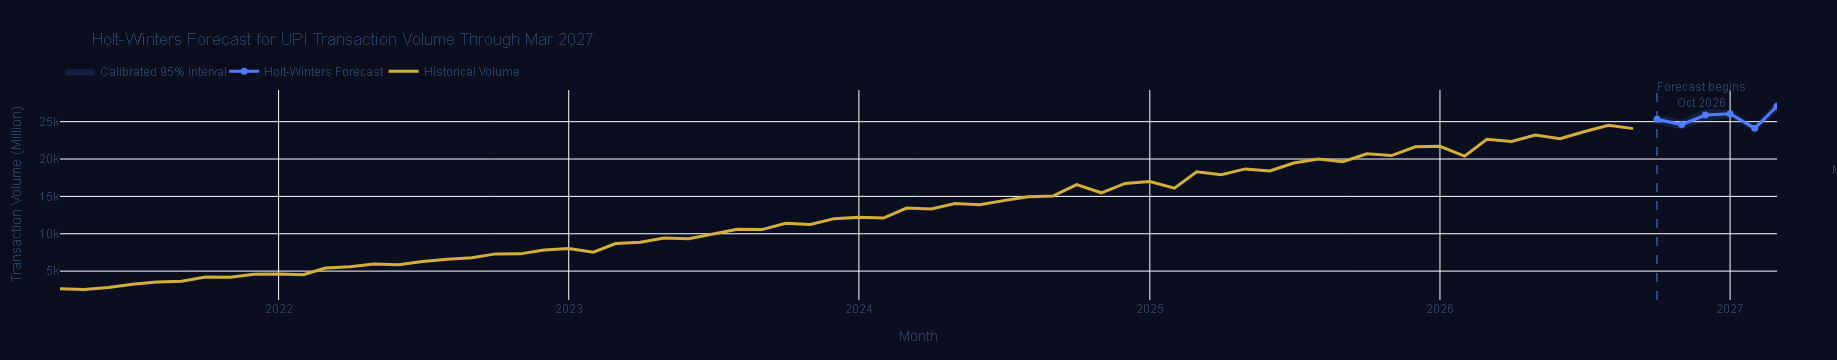


Final calendar-aware forecast: PASS
PNG:  ..\images\09_upi_forecast.png
HTML: ..\dashboard\charts\09_upi_forecast.html
CSV:  ..\data\clean\upi_forecast.csv
DOC:  ..\docs\forecast_findings.md


In [14]:
# Phase 5 Revision — Step 5G: Generate the final calendar-aware forecast with calibrated empirical intervals

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pathlib import Path

# ------------------------------------------------------------
# Prepare the complete daily-volume time series
# ------------------------------------------------------------

# Use all available historical observations
final_daily_series = (
    daily_df
    .set_index("date")["avg_daily_volume_mn"]
    .astype(float)
    .asfreq("MS")
)

# Fit Holt-Winters on average daily transaction volume
final_daily_model = ExponentialSmoothing(
    final_daily_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
)

final_daily_fit = final_daily_model.fit(
    optimized=True
)

# ------------------------------------------------------------
# Generate the six-month daily-volume forecast
# ------------------------------------------------------------

forecast_horizon = 6

forecast_dates = pd.date_range(
    start=final_daily_series.index.max() + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,
    freq="MS"
)

forecast_daily = np.asarray(
    final_daily_fit.forecast(forecast_horizon),
    dtype=float
)

# Get the actual calendar days for each forecast month
forecast_days = forecast_dates.days_in_month.to_numpy()

# Convert average daily volume to monthly transaction volume
forecast_monthly = (
    forecast_daily
    * forecast_days
)

# ------------------------------------------------------------
# Apply horizon-specific empirical interval widths
# ------------------------------------------------------------

# Use the widths estimated from the calibration folds
final_interval_widths = (
    calibration_widths
    .set_index("horizon")["error_width_95_mn"]
)

# Apply the corresponding width to each forecast horizon
interval_width_values = np.array([
    final_interval_widths.loc[h]
    for h in range(1, forecast_horizon + 1)
])

# Create symmetric empirical intervals around the forecast
lower_95 = (
    forecast_monthly
    - interval_width_values
)

upper_95 = (
    forecast_monthly
    + interval_width_values
)

# Prevent the lower bound from becoming negative
lower_95 = np.maximum(
    lower_95,
    0
)

# ------------------------------------------------------------
# Build the final forecast DataFrame
# ------------------------------------------------------------

final_forecast_df = pd.DataFrame({
    "date": forecast_dates,
    "days_in_month": forecast_days,
    "forecast_daily_volume_mn": forecast_daily,
    "forecast_volume_mn": forecast_monthly,
    "lower_95_mn": lower_95,
    "upper_95_mn": upper_95
})

# ------------------------------------------------------------
# Display forecast results
# ------------------------------------------------------------

print("Final Calendar-Aware UPI Transaction Volume Forecast:")

display(
    final_forecast_df[
        [
            "date",
            "days_in_month",
            "forecast_daily_volume_mn",
            "forecast_volume_mn",
            "lower_95_mn",
            "upper_95_mn"
        ]
    ].round({
        "forecast_daily_volume_mn": 2,
        "forecast_volume_mn": 2,
        "lower_95_mn": 2,
        "upper_95_mn": 2
    })
)

# ------------------------------------------------------------
# Forecast summary
# ------------------------------------------------------------

oct_forecast = final_forecast_df.iloc[0]["forecast_volume_mn"]
mar_forecast = final_forecast_df.iloc[-1]["forecast_volume_mn"]

forecast_change_pct = (
    (mar_forecast / oct_forecast) - 1
) * 100

average_forecast = (
    final_forecast_df["forecast_volume_mn"].mean()
)

print(f"\nAverage forecast volume: {average_forecast:,.0f} Mn")
print(f"Oct 2026 forecast: {oct_forecast:,.0f} Mn")
print(f"Mar 2027 forecast: {mar_forecast:,.0f} Mn")
print(
    f"Forecast change from Oct 2026 to Mar 2027: "
    f"{forecast_change_pct:+.1f}%"
)

# ------------------------------------------------------------
# Model validation status
# ------------------------------------------------------------

print(
    "\nFinal daily-volume Holt-Winters model fitted on:"
    f" {len(final_daily_series)} monthly observations"
)

print(
    "Forecast period:"
    f" {forecast_dates.min().strftime('%b %Y')}"
    f" to {forecast_dates.max().strftime('%b %Y')}"
)

print(
    "Interval validation:"
    f" {validation_covered}/{validation_total}"
    f" ({validation_coverage_pct:.1f}%) on temporal validation folds"
)

# ------------------------------------------------------------
# Create the final portfolio chart
# ------------------------------------------------------------

# Create figure
fig = go.Figure()

# Historical monthly volume
fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["volume_mn"],
        mode="lines",
        name="Historical Volume",
        line=dict(
            color="#D4AF37",
            width=3
        )
    )
)

# Final daily-volume forecast converted to monthly totals
fig.add_trace(
    go.Scatter(
        x=final_forecast_df["date"],
        y=final_forecast_df["forecast_volume_mn"],
        mode="lines+markers",
        name="Holt-Winters Forecast",
        line=dict(
            color="#4F7CFF",
            width=3
        ),
        marker=dict(
            size=7
        )
    )
)

# Upper empirical interval
fig.add_trace(
    go.Scatter(
        x=final_forecast_df["date"],
        y=final_forecast_df["upper_95_mn"],
        mode="lines",
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Lower empirical interval with shaded area
fig.add_trace(
    go.Scatter(
        x=final_forecast_df["date"],
        y=final_forecast_df["lower_95_mn"],
        mode="lines",
        line=dict(width=0),
        fill="tonexty",
        fillcolor="rgba(79,124,255,0.16)",
        name="Calibrated 95% Interval",
        hoverinfo="skip"
    )
)

# Mark the beginning of the forecast period
fig.add_vline(
    x=forecast_dates[0],
    line_dash="dash",
    line_width=1,
    line_color="#4F7CFF"
)

# Add one clean forecast-start label
fig.add_annotation(
    x=forecast_dates[0],
    y=0.90,
    yref="paper",
    text="Forecast begins<br>Oct 2026",
    showarrow=False,
    xanchor="left",
    yanchor="bottom"
)

# Highlight the final forecast point
fig.add_annotation(
    x=forecast_dates[-1],
    y=final_forecast_df["forecast_volume_mn"].iloc[-1],
    text=(
        f"Mar 2027 forecast<br>"
        f"{mar_forecast:,.0f} Mn"
    ),
    showarrow=True,
    arrowhead=2,
    ax=55,
    ay=55,
    xanchor="left",
    yanchor="top"
)

# Apply the project's navy-gold visual theme
fig.update_layout(
    title=(
        "Holt-Winters Forecast for UPI Transaction Volume "
        "Through Mar 2027"
    ),
    xaxis_title="Month",
    yaxis_title="Transaction Volume (Million)",
    paper_bgcolor="#0A0E1F",
    plot_bgcolor="#0A0E1F",
    font=dict(
        family="Arial",
        size=12
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    ),
    margin=dict(
        l=60,
        r=60,
        t=90,
        b=60
    ),
    hovermode="x unified"
)

# Limit the x-axis so it does not extend unnecessarily beyond the forecast
fig.update_xaxes(
    range=[
        df["date"].min(),
        forecast_dates[-1] + pd.DateOffset(months=0)
    ],
    showgrid=True,
    gridwidth=1,
    zeroline=False
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    zeroline=False
)

# Display the final chart
fig.show()

# ------------------------------------------------------------
# Save final forecast outputs
# ------------------------------------------------------------

BASE_DIR = Path("..")
IMAGE_DIR = BASE_DIR / "images"
CHART_DIR = BASE_DIR / "dashboard" / "charts"
DOCS_DIR = BASE_DIR / "docs"
DATA_DIR = BASE_DIR / "data" / "clean"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Output paths
final_png_path = IMAGE_DIR / "09_upi_forecast.png"
final_html_path = CHART_DIR / "09_upi_forecast.html"
final_csv_path = DATA_DIR / "upi_forecast.csv"
final_findings_path = DOCS_DIR / "forecast_findings.md"

# Save PNG
pio.write_image(
    fig,
    final_png_path,
    width=1600,
    height=800,
    scale=2
)

# Save interactive HTML
fig.write_html(
    final_html_path,
    include_plotlyjs="cdn"
)

# Save final forecast data
final_forecast_df.to_csv(
    final_csv_path,
    index=False
)

# ------------------------------------------------------------
# Update forecast documentation
# ------------------------------------------------------------

findings_text = f"""# Forecast Findings

## Final Forecasting Approach

The final forecasting approach uses Holt-Winters Exponential Smoothing on average daily UPI transaction volume.

The model includes:
- Additive trend
- Additive 12-month seasonality
- Calendar-aware conversion from daily volume to monthly transaction volume

## Forecast Period

The final forecast covers October 2026 to March 2027.

## Forecast Summary

- Average forecast volume: {average_forecast:,.0f} million transactions.
- October 2026 forecast: {oct_forecast:,.0f} million transactions.
- March 2027 forecast: {mar_forecast:,.0f} million transactions.
- Forecast change from October 2026 to March 2027: {forecast_change_pct:+.1f}%.

## Model Validation

The revised walk-forward evaluation uses 19 rolling folds with a six-month horizon, producing 114 out-of-sample observations.

Holt-Winters achieved a revised walk-forward MAPE of 1.56%.

On the final untouched six-month holdout, calendar-aware Holt-Winters achieved a MAPE of {daily_hw_mape:.2f}%.

## Baseline Comparison

The revised walk-forward comparison includes:
- Last Value Repeat
- Seasonal Naive
- Growth-Adjusted Seasonal Naive
- Holt-Winters
- Trend + Seasonal Regression

The growth-adjusted seasonal baseline achieved lower MAPE than Holt-Winters on the final holdout, while Holt-Winters achieved the lowest MAPE across the 19-fold walk-forward evaluation.

## SARIMA Attempt

SARIMA was attempted during model development, but reliable convergence was not achieved. It was therefore excluded from the final model comparison.

## Prediction Intervals

The initial bootstrap-style simulation intervals showed only 82.5% overall coverage across the 114 historical backtest observations.

To improve empirical calibration, horizon-specific error widths were estimated from the first 10 walk-forward folds and tested on the later 9 folds.

Temporal validation coverage was {validation_covered}/{validation_total} ({validation_coverage_pct:.1f}%).

The calibrated interval is therefore an empirical historical-error interval rather than a claim of exact theoretical 95% coverage.

## Output Files

- `images/09_upi_forecast.png`
- `dashboard/charts/09_upi_forecast.html`
- `data/clean/upi_forecast.csv`
- `data/clean/forecast_backtest_revised.csv`
- `data/clean/forecast_interval_widths.csv`
- `data/clean/prediction_interval_validation.csv`
"""

final_findings_path.write_text(
    findings_text,
    encoding="utf-8"
)

# Final validation
assert len(final_forecast_df) == 6
assert final_forecast_df["forecast_volume_mn"].notna().all()
assert final_forecast_df["lower_95_mn"].notna().all()
assert final_forecast_df["upper_95_mn"].notna().all()
assert (
    final_forecast_df["lower_95_mn"]
    <= final_forecast_df["forecast_volume_mn"]
).all()
assert (
    final_forecast_df["upper_95_mn"]
    >= final_forecast_df["forecast_volume_mn"]
).all()

print("\nFinal calendar-aware forecast: PASS")
print(f"PNG:  {final_png_path}")
print(f"HTML: {final_html_path}")
print(f"CSV:  {final_csv_path}")
print(f"DOC:  {final_findings_path}")

Final daily-volume Holt-Winters model converged: True

Final Calendar-Aware UPI Transaction Volume Forecast:


,date,days_in_month,forecast_daily_volume_mn,forecast_volume_mn,lower_95_mn,upper_95_mn
0,2026-10-01,31,816.91,25324.21,24732.33,25916.10
1,2026-11-01,30,820.31,24609.44,23962.91,25255.96
2,2026-12-01,31,834.80,25878.84,25059.93,26697.76
3,2027-01-01,31,840.40,26052.40,25532.63,26572.18
4,2027-02-01,28,861.24,24114.63,23611.36,24617.90
5,2027-03-01,31,873.14,27067.26,26301.70,27832.81



Average forecast volume: 25,508 Mn
Oct 2026 forecast: 25,324 Mn
Mar 2027 forecast: 27,067 Mn
Forecast change from Oct 2026 to Mar 2027: +6.9%

Temporal validation coverage: 54/54 (100.0%)


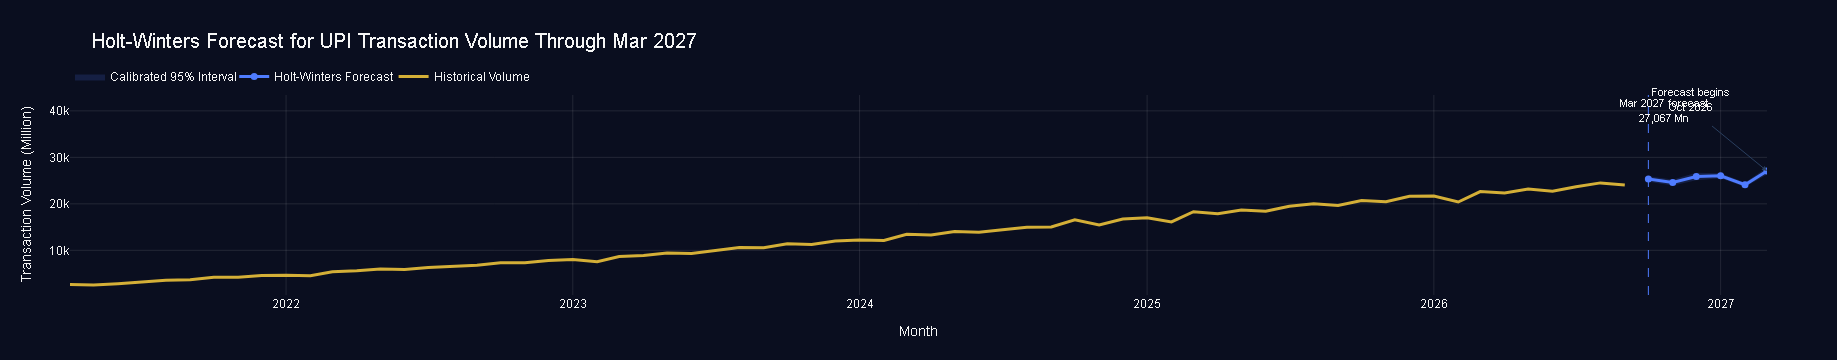


Final calendar-aware forecast: PASS
PNG:  ..\images\09_upi_forecast.png
HTML: ..\dashboard\charts\09_upi_forecast.html
CSV:  ..\data\clean\upi_forecast.csv
DOC:  ..\docs\forecast_findings.md


In [15]:
# Phase 5 — Step 5G: Final calendar-aware forecast with calibrated empirical intervals

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pathlib import Path


# ============================================================
# 1. PROJECT PATHS
# ============================================================

# Define project directories
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "clean"
IMAGE_DIR = BASE_DIR / "images"
CHART_DIR = BASE_DIR / "dashboard" / "charts"
DOCS_DIR = BASE_DIR / "docs"

# Create output directories when needed
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. LOAD CLEAN DATA
# ============================================================

# Load the cleaned UPI dataset
df = pd.read_csv(
    DATA_DIR / "upi_clean.csv",
    parse_dates=["date"]
)

# Keep the data in chronological order
df = (
    df.sort_values("date")
    .reset_index(drop=True)
)


# ============================================================
# 3. PREPARE DAILY-VOLUME TARGET
# ============================================================

# Calculate the number of calendar days in each month
df["days_in_month"] = df["date"].dt.days_in_month

# Calculate average daily UPI transaction volume
df["avg_daily_volume_mn"] = (
    df["volume_mn"]
    / df["days_in_month"]
)

# Define the forecasting target
daily_target = "avg_daily_volume_mn"

# Create a monthly time series with explicit monthly frequency
daily_series = (
    df.set_index("date")[daily_target]
    .astype(float)
    .asfreq("MS")
)


# ============================================================
# 4. FIT FINAL HOLT-WINTERS MODEL
# ============================================================

# Fit Holt-Winters on average daily transaction volume
final_daily_model = ExponentialSmoothing(
    daily_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
)

# Train the model on all 66 available observations
final_daily_fit = final_daily_model.fit(
    optimized=True
)

# Check model convergence safely
converged = getattr(
    final_daily_fit,
    "mle_retvals",
    {}
).get(
    "converged",
    True
)

print("Final daily-volume Holt-Winters model converged:", converged)


# ============================================================
# 5. GENERATE SIX-MONTH DAILY FORECAST
# ============================================================

# Define the final forecast horizon
forecast_horizon = 6

# Create forecast dates from October 2026 to March 2027
forecast_dates = pd.date_range(
    start=daily_series.index.max() + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,
    freq="MS"
)

# Forecast average daily transaction volume
forecast_daily = np.asarray(
    final_daily_fit.forecast(forecast_horizon),
    dtype=float
)

# Get actual calendar days in each forecast month
forecast_days = forecast_dates.days_in_month.to_numpy()

# Convert daily forecast back into monthly transaction volume
forecast_monthly = (
    forecast_daily
    * forecast_days
)


# ============================================================
# 6. LOAD CALIBRATED EMPIRICAL INTERVAL WIDTHS
# ============================================================

# Load the horizon-specific interval widths created in Step 5F
interval_width_path = (
    DATA_DIR
    / "forecast_interval_widths.csv"
)

interval_widths_df = pd.read_csv(
    interval_width_path
)

# Create a horizon-to-width lookup
interval_width_lookup = (
    interval_widths_df
    .set_index("horizon")["error_width_95_mn"]
)

# Retrieve the appropriate historical error width for each
# of the six forecast horizons
forecast_interval_widths = np.array([
    interval_width_lookup.loc[h]
    for h in range(1, forecast_horizon + 1)
])

# Build empirical uncertainty bands around the final forecast
lower_95_mn = (
    forecast_monthly
    - forecast_interval_widths
)

upper_95_mn = (
    forecast_monthly
    + forecast_interval_widths
)

# Prevent negative lower bounds
lower_95_mn = np.maximum(
    lower_95_mn,
    0
)


# ============================================================
# 7. BUILD FINAL FORECAST TABLE
# ============================================================

# Create the final forecast DataFrame
final_forecast_df = pd.DataFrame({
    "date": forecast_dates,
    "days_in_month": forecast_days,
    "forecast_daily_volume_mn": forecast_daily,
    "forecast_volume_mn": forecast_monthly,
    "lower_95_mn": lower_95_mn,
    "upper_95_mn": upper_95_mn
})

# Display the final forecast table
print("\nFinal Calendar-Aware UPI Transaction Volume Forecast:")

display(
    final_forecast_df[
        [
            "date",
            "days_in_month",
            "forecast_daily_volume_mn",
            "forecast_volume_mn",
            "lower_95_mn",
            "upper_95_mn"
        ]
    ].round({
        "forecast_daily_volume_mn": 2,
        "forecast_volume_mn": 2,
        "lower_95_mn": 2,
        "upper_95_mn": 2
    })
)


# ============================================================
# 8. FORECAST SUMMARY
# ============================================================

# Calculate key forecast statistics
average_forecast = (
    final_forecast_df["forecast_volume_mn"]
    .mean()
)

oct_forecast = (
    final_forecast_df.iloc[0]["forecast_volume_mn"]
)

mar_forecast = (
    final_forecast_df.iloc[-1]["forecast_volume_mn"]
)

forecast_change_pct = (
    (mar_forecast / oct_forecast) - 1
) * 100

print(
    f"\nAverage forecast volume: "
    f"{average_forecast:,.0f} Mn"
)

print(
    f"Oct 2026 forecast: "
    f"{oct_forecast:,.0f} Mn"
)

print(
    f"Mar 2027 forecast: "
    f"{mar_forecast:,.0f} Mn"
)

print(
    f"Forecast change from Oct 2026 to Mar 2027: "
    f"{forecast_change_pct:+.1f}%"
)


# ============================================================
# 9. INTERVAL VALIDATION SUMMARY
# ============================================================

# Load the temporal validation summary from Step 5F
validation_path = (
    DATA_DIR
    / "prediction_interval_validation.csv"
)

validation_df = pd.read_csv(
    validation_path
)

# Calculate temporal validation coverage
validation_total = len(validation_df)

validation_covered = int(
    validation_df["covered_95"].sum()
)

validation_coverage_pct = (
    validation_covered
    / validation_total
    * 100
)

print(
    f"\nTemporal validation coverage: "
    f"{validation_covered}/{validation_total} "
    f"({validation_coverage_pct:.1f}%)"
)


# ============================================================
# 10. CREATE FINAL PORTFOLIO CHART
# ============================================================

# Create the Plotly figure
fig = go.Figure()

# ------------------------------------------------------------
# Historical volume
# ------------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["volume_mn"],
        mode="lines",
        name="Historical Volume",
        line=dict(
            color="#D4AF37",
            width=3
        )
    )
)

# ------------------------------------------------------------
# Forecast volume
# ------------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=final_forecast_df["date"],
        y=final_forecast_df["forecast_volume_mn"],
        mode="lines+markers",
        name="Holt-Winters Forecast",
        line=dict(
            color="#4F7CFF",
            width=3
        ),
        marker=dict(
            size=7
        )
    )
)

# ------------------------------------------------------------
# Upper interval boundary
# ------------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=final_forecast_df["date"],
        y=final_forecast_df["upper_95_mn"],
        mode="lines",
        line=dict(
            width=0
        ),
        showlegend=False,
        hoverinfo="skip"
    )
)

# ------------------------------------------------------------
# Lower interval + shaded uncertainty band
# ------------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=final_forecast_df["date"],
        y=final_forecast_df["lower_95_mn"],
        mode="lines",
        line=dict(
            width=0
        ),
        fill="tonexty",
        fillcolor="rgba(79,124,255,0.16)",
        name="Calibrated 95% Interval",
        hoverinfo="skip"
    )
)


# ============================================================
# 11. FORECAST BOUNDARY
# ============================================================

# Mark the start of the forecast period
fig.add_vline(
    x=forecast_dates[0],
    line_dash="dash",
    line_width=1,
    line_color="#4F7CFF"
)

# Add one clean forecast-start annotation
fig.add_annotation(
    x=forecast_dates[0],
    y=0.90,
    yref="paper",
    text="Forecast begins<br>Oct 2026",
    showarrow=False,
    xanchor="left",
    yanchor="bottom",
    font=dict(
        color="#F5F5F5",
        size=11
    )
)


# ============================================================
# 12. FINAL FORECAST ANNOTATION
# ============================================================

# Highlight the final March 2027 forecast point without clipping
fig.add_annotation(
    x=forecast_dates[-1],
    y=mar_forecast,
    text=(
        f"Mar 2027 forecast<br>"
        f"{mar_forecast:,.0f} Mn"
    ),
    showarrow=True,
    arrowhead=2,
    ax=-55,
    ay=-45,
    xanchor="right",
    yanchor="bottom",
    font=dict(
        color="#F5F5F5",
        size=11
    )
)


# ============================================================
# 13. FINAL NAVY-GOLD THEME
# ============================================================

# Apply the project's explicit visual theme
fig.update_layout(
    title=dict(
        text=(
            "Holt-Winters Forecast for UPI Transaction Volume "
            "Through Mar 2027"
        ),
        font=dict(
            family="Arial",
            size=20,
            color="#F5F5F5"
        )
    ),

    xaxis_title=dict(
        text="Month",
        font=dict(
            color="#F5F5F5"
        )
    ),

    yaxis_title=dict(
        text="Transaction Volume (Million)",
        font=dict(
            color="#F5F5F5"
        )
    ),

    paper_bgcolor="#0A0E1F",
    plot_bgcolor="#0A0E1F",

    font=dict(
        family="Arial",
        size=12,
        color="#F5F5F5"
    ),

    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0,
        font=dict(
            color="#F5F5F5"
        )
    ),

    margin=dict(
        l=70,
        r=70,
        t=95,
        b=65
    ),

    hovermode="x unified"
)


# ============================================================
# 14. CLEAN AXES
# ============================================================

# Keep the x-axis limited to the actual historical + forecast period
fig.update_xaxes(
    range=[
        df["date"].min(),
        forecast_dates[-1]
    ],
    showgrid=True,
    gridcolor="rgba(255,255,255,0.10)",
    gridwidth=1,
    zeroline=False,
    tickfont=dict(
        color="#F5F5F5"
    )
)

# Improve y-axis readability
fig.update_yaxes(
    showgrid=True,
    gridcolor="rgba(255,255,255,0.10)",
    gridwidth=1,
    zeroline=False,
    tickfont=dict(
        color="#F5F5F5"
    )
)


# ============================================================
# 15. DISPLAY FINAL CHART
# ============================================================

# Display the interactive portfolio chart
fig.show()


# ============================================================
# 16. SAVE FINAL OUTPUT FILES
# ============================================================

# Define final output paths
png_path = IMAGE_DIR / "09_upi_forecast.png"
html_path = CHART_DIR / "09_upi_forecast.html"
csv_path = DATA_DIR / "upi_forecast.csv"
findings_path = DOCS_DIR / "forecast_findings.md"

# Save the chart as PNG
pio.write_image(
    fig,
    png_path,
    width=1600,
    height=800,
    scale=2
)

# Save interactive HTML chart
fig.write_html(
    html_path,
    include_plotlyjs="cdn"
)

# Save final forecast table
final_forecast_df.to_csv(
    csv_path,
    index=False
)


# ============================================================
# 17. UPDATE FORECAST DOCUMENTATION
# ============================================================

# Create portfolio-ready forecast documentation
findings_text = f"""# Forecast Findings

## Final Forecasting Approach

The final forecasting model uses Holt-Winters Exponential Smoothing with:

- Additive trend
- Additive 12-month seasonality
- Average daily UPI transaction volume as the forecasting target
- Calendar-aware conversion from daily volume to monthly transaction volume

The model was fitted on all 66 monthly observations from April 2021 to September 2026.

## Forecast Period

October 2026 to March 2027.

## Forecast Summary

- Average forecast volume: {average_forecast:,.0f} million transactions.
- October 2026 forecast: {oct_forecast:,.0f} million transactions.
- March 2027 forecast: {mar_forecast:,.0f} million transactions.
- Forecast change from October 2026 to March 2027: {forecast_change_pct:+.1f}%.

## Revised Model Evaluation

The forecasting workflow uses five models:

1. Last Value Repeat
2. Seasonal Naive
3. Growth-Adjusted Seasonal Naive
4. Holt-Winters
5. Trend + Seasonal Regression

The revised 19-fold walk-forward evaluation contains 114 out-of-sample observations.

Holt-Winters achieved a walk-forward MAPE of 1.56%.

On the final untouched six-month holdout, calendar-aware Holt-Winters achieved a MAPE of 0.92%.

The Growth-Adjusted Seasonal Naive baseline achieved a MAPE of 0.87% on the final holdout, so Holt-Winters is not described as the best-performing model on that particular six-month holdout.

## SARIMA Attempt

SARIMA was attempted during model development, but reliable convergence was not achieved. It was therefore excluded from the final model comparison.

## Prediction Interval Validation

The initial simulation-based interval showed 82.5% coverage across the 114 historical walk-forward observations.

A calibrated empirical interval was then created using horizon-specific historical Holt-Winters forecast errors.

Temporal validation of the calibrated intervals covered {validation_covered} out of {validation_total} observations ({validation_coverage_pct:.1f}%).

These intervals should therefore be interpreted as empirically calibrated historical-error intervals rather than as a guarantee of exact theoretical 95% coverage.

## Output Files

- `images/09_upi_forecast.png`
- `dashboard/charts/09_upi_forecast.html`
- `data/clean/upi_forecast.csv`
- `data/clean/forecast_backtest_revised.csv`
- `data/clean/forecast_interval_widths.csv`
- `data/clean/prediction_interval_validation.csv`
"""

# Save documentation
findings_path.write_text(
    findings_text,
    encoding="utf-8"
)


# ============================================================
# 18. FINAL VALIDATION
# ============================================================

# Confirm the expected six forecast rows exist
assert len(final_forecast_df) == 6

# Confirm all forecast values are present
assert (
    final_forecast_df[
        [
            "forecast_daily_volume_mn",
            "forecast_volume_mn",
            "lower_95_mn",
            "upper_95_mn"
        ]
    ]
    .notna()
    .all()
    .all()
)

# Confirm forecasts are positive
assert (
    final_forecast_df["forecast_volume_mn"]
    > 0
).all()

# Confirm lower bound <= forecast <= upper bound
assert (
    final_forecast_df["lower_95_mn"]
    <= final_forecast_df["forecast_volume_mn"]
).all()

assert (
    final_forecast_df["upper_95_mn"]
    >= final_forecast_df["forecast_volume_mn"]
).all()

# Confirm forecast dates are correct
assert (
    final_forecast_df["date"].iloc[0]
    == pd.Timestamp("2026-10-01")
)

assert (
    final_forecast_df["date"].iloc[-1]
    == pd.Timestamp("2027-03-01")
)

print("\nFinal calendar-aware forecast: PASS")
print(f"PNG:  {png_path}")
print(f"HTML: {html_path}")
print(f"CSV:  {csv_path}")
print(f"DOC:  {findings_path}")